In [36]:
# using Pkg; Pkg.activate("notebook"; shared=true)
using LinearAlgebra, StaticArrays, Statistics, Test, UnPack, Parameters

# load Makie plotting
using CairoMakie, ColorSchemes
pal = colorschemes[:Set1_9]
set_theme!(palette = (color = pal, marker = [:circle, :xcross]))
using DelimitedFiles,FFTW,Interpolations,ImageFiltering
using Optim

# Strategy:

1. Import data
2. Identify a base triangle -> all triangles
3. Identify initial parameters -> fit
4. Plot statistics

In [37]:
arot(θ) = SMatrix{2,2,Float64}(cos(θ),sin(θ),-sin(θ),cos(θ))
function get_triangle(R1,R2,vertices;threshold=0.4)
    triangles = Vector{Vector{Point{2,Float64}}}()
    for t1 in vertices
        i2 = findmin(v->norm((t1 + R1)- v),vertices)[2]
        i3 = findmin(v->norm((t1 + R2)- v),vertices)[2]
        # @show i2, i3
        t2 = vertices[i2]
        t3 = vertices[i3]
        if norm(t1+R1 - t2) < norm(R1)*threshold && norm(t1+R2 - t3) < norm(R1)*threshold && length(unique([t1,t2,t3])) == 3
            push!(triangles,Point2f.([t1,t2,t3]))
        end
    end
    return triangles
end

# alpha -radians
# epsilon - percent
# phi - radians
# theta - radians
function strainedlattice(α,ϵpercent,ϕ,θ)
    a = 0.3551 #nm
    νPoisson = 0.25
    A1 = @SArray [a/2,-a*sqrt(3)/2]
    A2 = @SArray [a,0]
    R = arot(ϕ)
    ϵ = ϵpercent*0.01
    S = R' * SMatrix{2,2,Float64,4}(-ϵ,0,0,ϵ*νPoisson) * R
    T = S + SMatrix{2,2,Float64,4}(0,-θ,θ,0)
    M = arot(α) * inv(T)
    a1 = M*A1
    a2 = M*A2
    return a1,a2
end

function L(params, uptriangle)
    a1, a2 = strainedlattice(params...)
    a3 = -a1+a2
    t1, t2, t3 = uptriangle
    R1 = t2-t1
    R2 = t3-t1
    R3 = t3-t2
    return norm(a1-R1) + norm(a2-R2) + norm(a3-R3)
end



# area sign (positive = CCW)
function tri_area(tri)
    t1,t2,t3 = tri
    return 0.5*((t2[1]-t1[1])*(t3[2]-t1[2]) - (t2[2]-t1[2])*(t3[1]-t1[1]))
end

# force CCW order as (t1,t2,t3) around t1
function canonicalize(tri)
    t1,t2,t3 = tri
    if tri_area((t1,t2,t3)) ≥ 0
        return (t1,t2,t3)
    else
        return (t1,t3,t2)   # swap to make CCW
    end
end



canonicalize (generic function with 1 method)

# Dataset1

## Assign Triangles

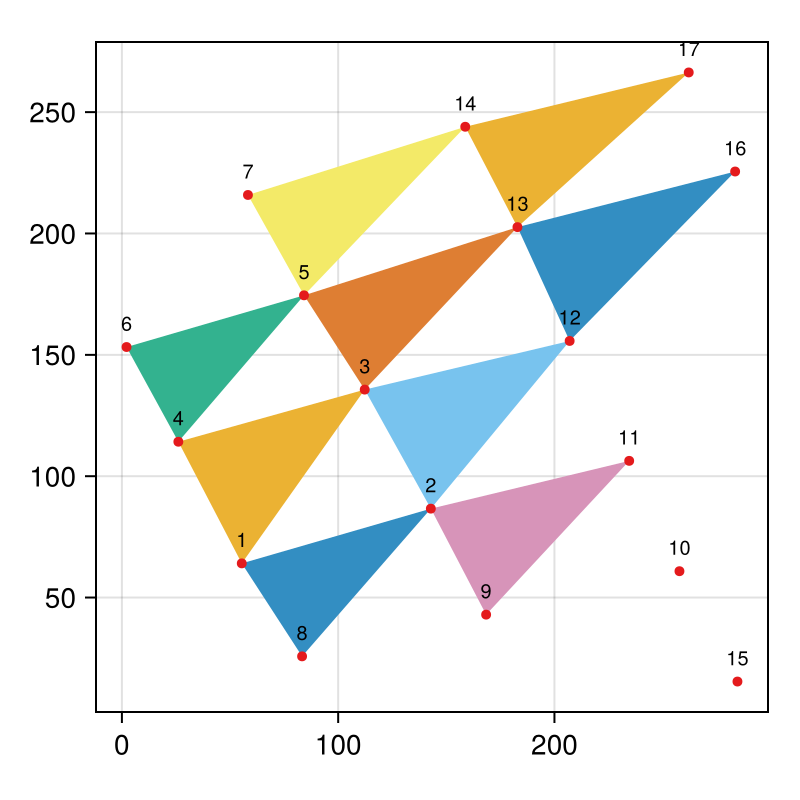

CairoMakie.Screen{IMAGE}


In [ ]:
folder = ""

files  = sort(readdir(folder; join=true))

# Read as Float64 to avoid Any-typed matrices
data = [readdlm(file, ',' , Float64) for file in files]

# Points for Makie
vertices = [Point2f(dat[i,1], dat[i,2]) for i in 1:size(dat,1)]
Np = length(vertices)

# Your geometry

#PFM1
# R1up = vertices[1] - vertices[26]
# R2up = vertices[2] - vertices[26]

#PFM2
# R1up = vertices[6] - vertices[9]
# R2up = vertices[3] - vertices[9]

#PFM3
#R1up = vertices[1] - vertices[2]
#R2up = vertices[8] - vertices[2]

#PFM4
# R1up = vertices[23] - vertices[24]
# R2up = vertices[30] - vertices[24]


up_triangles = get_triangle(R1up, R2up, vertices)

up_triangles1 =  up_triangles;

# Figure 1: up triangles
fig1 = Figure(size = (400, 400))
ax1  = Axis(fig1[1,1], aspect = 1)
for t in up_triangles
    poly!(ax1, Point2f.(t))
end
scatter!(ax1, vertices; markersize = 7)
text!(ax1, vertices; text = string.(1:Np), align = (:center,:bottom), offset = (0,6), fontsize = 10)

display(fig1)


## Identify initial guess

Loss for initial guess: 591.2780758743479
Loss after fitting: 1.6136966311249917e-7
rad2deg(params1[1]) = 139.54817206832573
params1[2] = 0.31395849644973384
rad2deg(params1[3]) = -16.99192512245347
rad2deg(params1[4]) = 0.31338464810995836


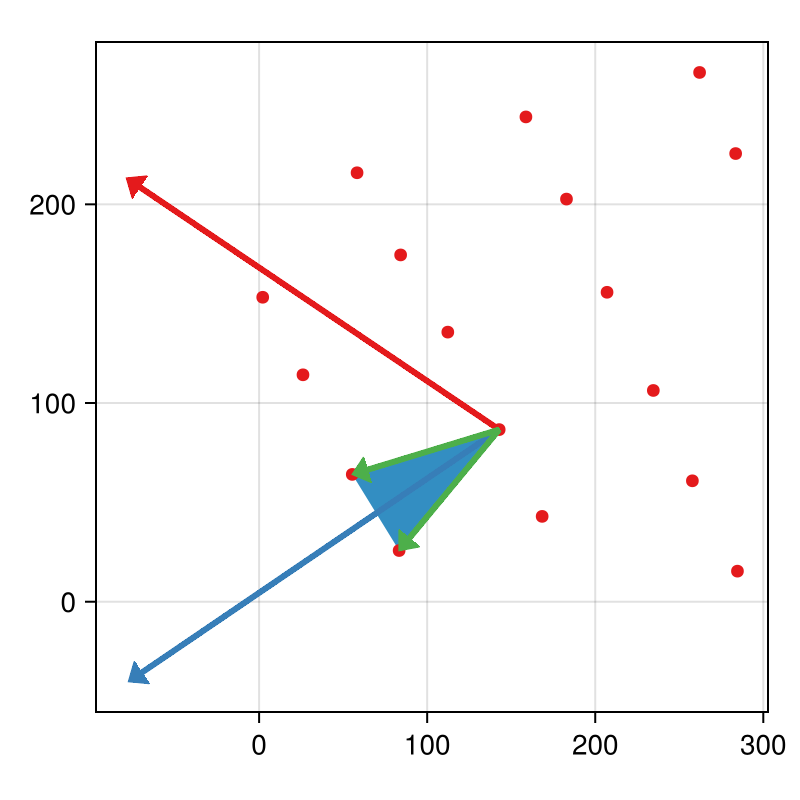

CairoMakie.Screen{IMAGE}


In [282]:
tri0 = up_triangles[1]
t0 = tri0[1]
params0 = [deg2rad(120),0.001,deg2rad(-1),deg2rad(0.08)]
a1,a2 = strainedlattice(params0...)
println("Loss for initial guess: ", L(params0,tri0))

opt = Optim.optimize(p -> L(p,tri0),params0)
println("Loss after fitting: ", Optim.minimum(opt))
params1 = Optim.minimizer(opt)
a1opt,a2opt = strainedlattice(params1...)
@show rad2deg(params1[1])
@show params1[2]
@show rad2deg(params1[3])
@show rad2deg(params1[4])

fig = Figure(size=(400,400))
ax = Axis(fig[1,1],aspect=1)
for t in up_triangles[1:1]
    poly!(ax,Point2f.(t))
end
scatter!(ax,vertices)
arrows2d!(ax,[t0],[a1],color=pal[1])
arrows2d!(ax,[t0],[a2],color=pal[2])
arrows2d!(ax,[t0,t0],[a1opt,a2opt],color=pal[3])

display(fig)


## Do Fits

In [283]:
fits1 = [optimize(p -> L(p,tri),params1) for tri in up_triangles];

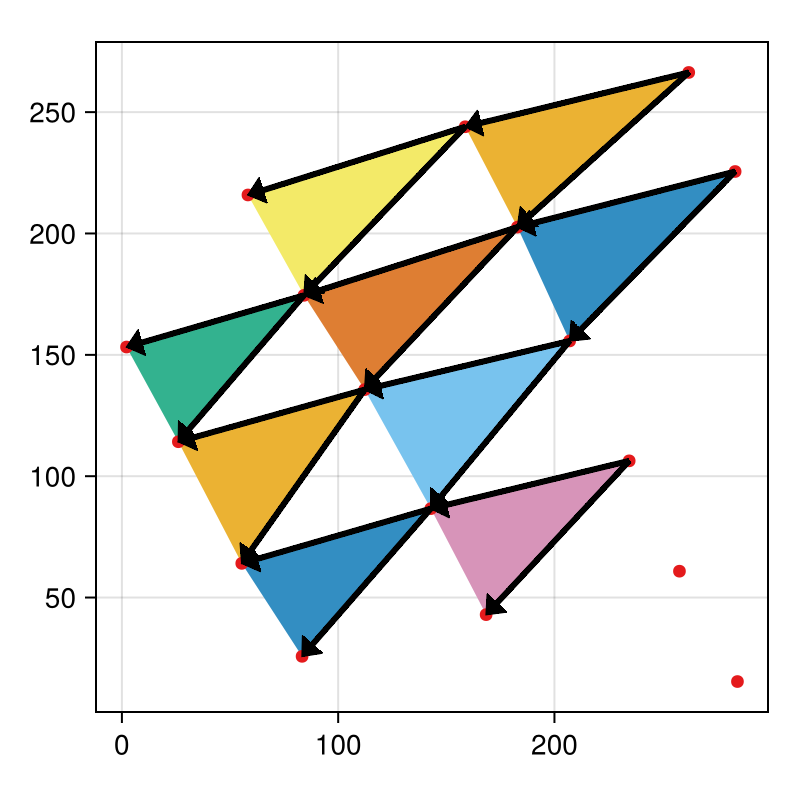

In [284]:
fig = Figure(size=(400,400))
ax = Axis(fig[1,1],aspect=1)
for t in up_triangles
    poly!(ax,Point2f.(t))
end
scatter!(ax,vertices)
for n in eachindex(up_triangles)
    t0 = up_triangles[n][1]
    a1opt, a2opt = strainedlattice(Optim.minimizer(fits1[n])...)
    arrows2d!(ax,[t0,t0],[a1opt,a2opt])
end
fig

## Show Statistics

mean strain: 0.29655963224927
mean angle: 0.2914275758593801


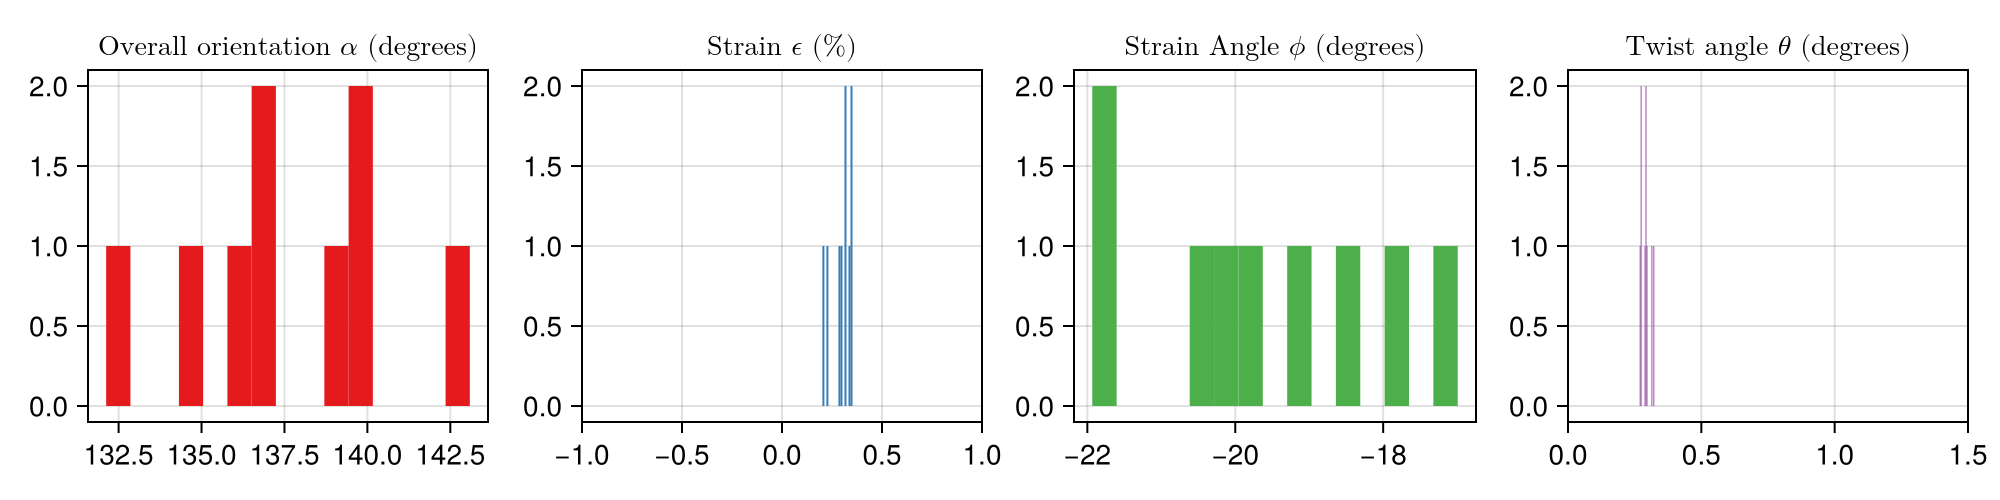

In [285]:
fit_params = stack(Optim.minimizer.(fits1))
println("mean strain: ", mean(fit_params[2,:]))
println("mean angle: ", rad2deg(mean(fit_params[4,:])))

fig = Figure(size=(1000,250))
ax = Axis(fig[1,1],title=L"Overall orientation $\alpha$ (degrees)")
hist!(ax,rad2deg.(fit_params[1,:]),color=pal[1])
ax = Axis(fig[1,2],title=L"Strain $\epsilon$ (%)")
hist!(ax,(fit_params[2,:]),color=pal[2])
xlims!(ax,-1,1.0)
ax = Axis(fig[1,3],title=L"Strain Angle $\phi$ (degrees)")
hist!(ax,rad2deg.(fit_params[3,:]),color=pal[3])
ax = Axis(fig[1,4],title=L"Twist angle $\theta$ (degrees)")
hist!(ax,rad2deg.(fit_params[4,:]),color=pal[4])
xlims!(ax,0,1.5)

fit_params1 = stack(Optim.minimizer.(fits1))


fig



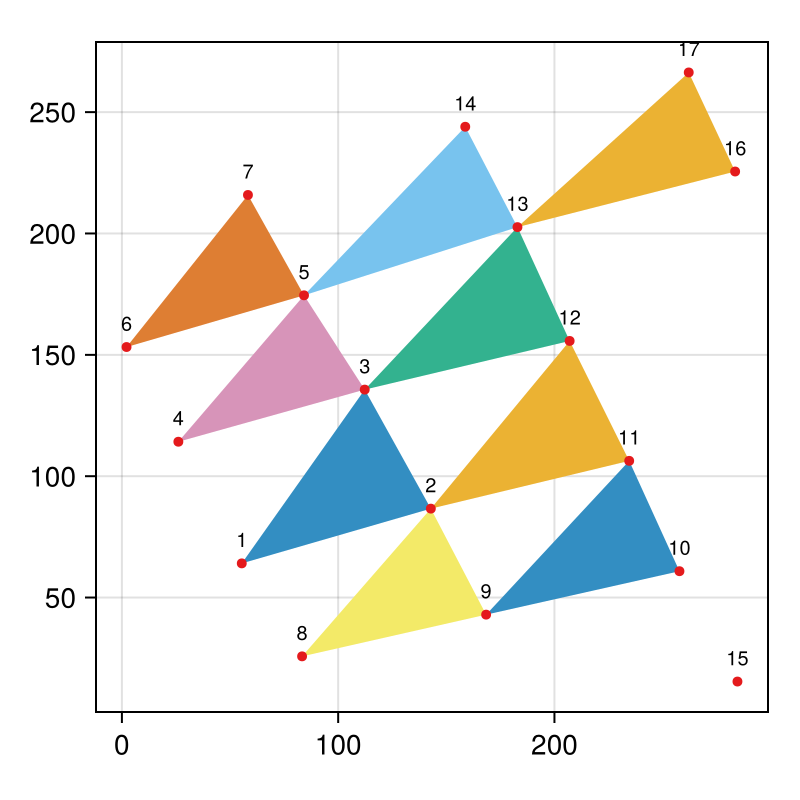

CairoMakie.Screen{IMAGE}


In [ ]:
# Your geometry

#PFM1
# R1up = vertices[15] - vertices[8]
# R2up = vertices[16] - vertices[8]

#PFM2
# R1up = vertices[6] - vertices[2]
# R2up = vertices[3] - vertices[2]

#PFM3
#R1up = vertices[9] - vertices[8]
#R2up = vertices[2] - vertices[8]

#PFM4
# R1up = vertices[30] - vertices[36]
# R2up = vertices[37] - vertices[36]

up_triangles = get_triangle(R1up, R2up, vertices)

down_triangles1 =  up_triangles;

# Figure 1: up triangles
fig1 = Figure(size = (400, 400))
ax1  = Axis(fig1[1,1], aspect = 1)
for t in up_triangles
    poly!(ax1, Point2f.(t))
end
scatter!(ax1, vertices; markersize = 7)
text!(ax1, vertices; text = string.(1:Np), align = (:center,:bottom), offset = (0,6), fontsize = 10)


display(fig1)


Loss for initial guess1: 601.7752745660081
Loss after fitting: 3.382704861420758e-8
rad2deg(params1[1]) = -36.46579492359893
params1[2] = 0.20613201464411693
rad2deg(params1[3]) = -20.621483452255205
rad2deg(params1[4]) = 0.2747941109612104


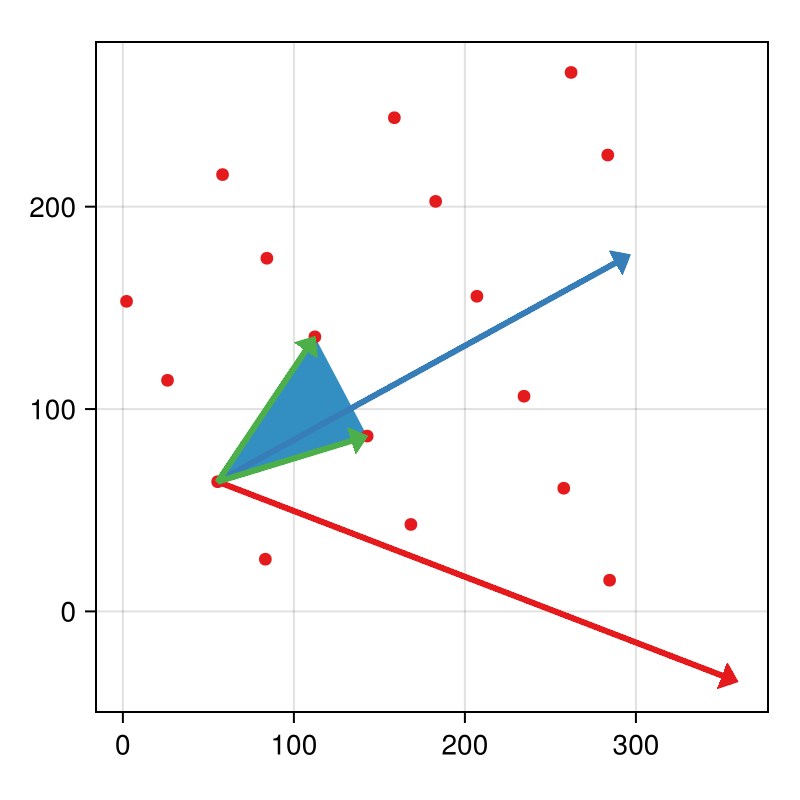

CairoMakie.Screen{IMAGE}


In [287]:
tri0  = canonicalize(up_triangles[1])
t0 = tri0[1]
params0 = [deg2rad(-60),0.05,deg2rad(-1),deg2rad(0.08)]
a1,a2 = strainedlattice(params0...)
println("Loss for initial guess1: ", L(params0,tri0))

opt = Optim.optimize(p -> L(p,tri0),params0)
println("Loss after fitting: ", Optim.minimum(opt))
params1 = Optim.minimizer(opt)
a1opt,a2opt = strainedlattice(params1...)
@show rad2deg(params1[1])
@show params1[2]
@show rad2deg(params1[3])
@show rad2deg(params1[4])

fig = Figure(size=(400,400))
ax = Axis(fig[1,1],aspect=1)
for t in up_triangles[1:1]
    poly!(ax,Point2f.(t))
end
scatter!(ax,vertices)
arrows2d!(ax,[t0],[a1],color=pal[1])
arrows2d!(ax,[t0],[a2],color=pal[2])
arrows2d!(ax,[t0,t0],[a1opt,a2opt],color=pal[3])

display(fig)

In [288]:
fits1 = [optimize(p -> L(p, canonicalize(tri)), params1) for tri in up_triangles]

9-element Vector{Optim.MultivariateOptimizationResults{NelderMead{Optim.AffineSimplexer, Optim.AdaptiveParameters}, Vector{Float64}, Float64, Float64, Vector{OptimizationState{Float64, NelderMead{Optim.AffineSimplexer, Optim.AdaptiveParameters}}}, @NamedTuple{x_converged::Bool, f_converged::Bool, g_converged::Bool, f_limit_reached::Bool, g_limit_reached::Bool, h_limit_reached::Bool, time_limit::Bool, callback::Bool, f_increased::Bool, ls_failed::Bool, iterations::Bool}}}:
  * Status: success

 * Candidate solution
    Final objective value:     2.654023e-08

 * Found with
    Algorithm:     Nelder-Mead

 * Convergence measures
    √(Σ(yᵢ-ȳ)²)/n ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs limit Inf)
    Iterations:    324
    f(x) calls:    511

  * Status: success

 * Candidate solution
    Final objective value:     3.933669e-08

 * Found with
    Algorithm:     Nelder-Mead

 * Convergence measures
    √(Σ(yᵢ-ȳ)²)/n ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs lim

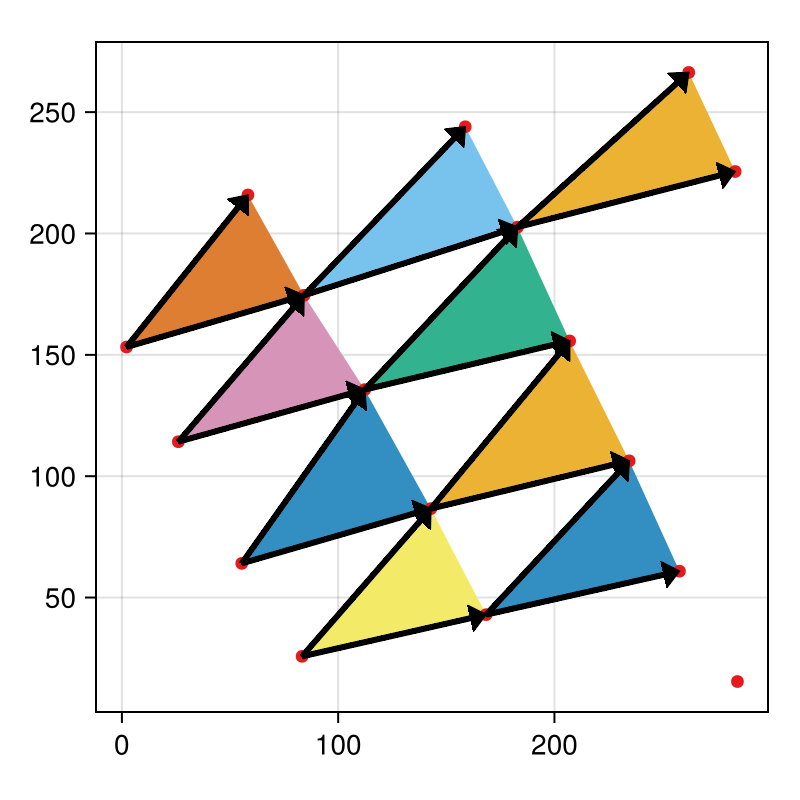

In [289]:
fig = Figure(size=(400,400))
ax = Axis(fig[1,1],aspect=1)
for t in up_triangles
    poly!(ax,Point2f.(t))
end
scatter!(ax,vertices)
for n in eachindex(up_triangles)
    t0 = up_triangles[n][1]
    a1opt, a2opt = strainedlattice(Optim.minimizer(fits1[n])...)
    arrows2d!(ax,[t0,t0],[a1opt,a2opt])
end
fig

mean strain: 0.2826119517928793
mean angle: 0.2935605097074137


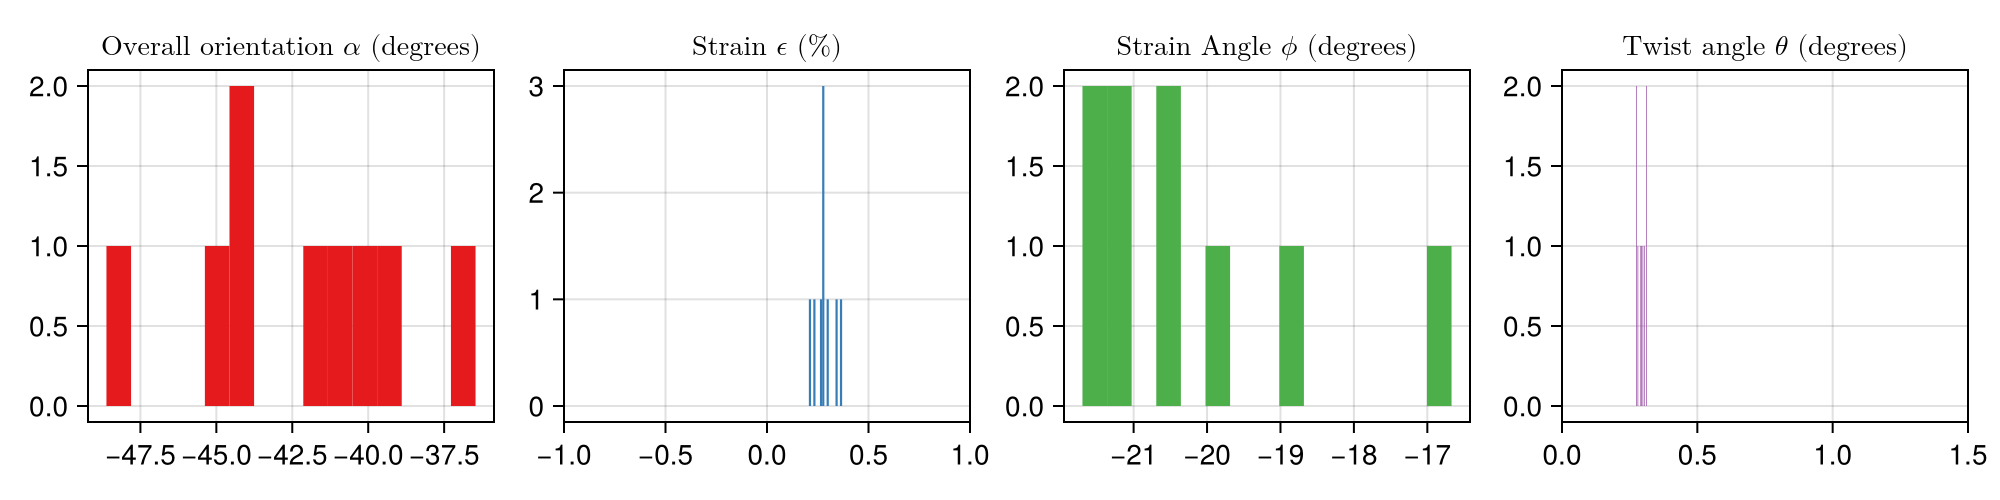

In [290]:
fit_params = stack(Optim.minimizer.(fits1))
println("mean strain: ", mean(fit_params[2,:]))
println("mean angle: ", rad2deg(mean(fit_params[4,:])))

fig = Figure(size=(1000,250))
ax = Axis(fig[1,1],title=L"Overall orientation $\alpha$ (degrees)")
hist!(ax,rad2deg.(fit_params[1,:]),color=pal[1])
ax = Axis(fig[1,2],title=L"Strain $\epsilon$ (%)")
hist!(ax,fit_params[2,:],color=pal[2])
xlims!(ax,-1,1.0)
ax = Axis(fig[1,3],title=L"Strain Angle $\phi$ (degrees)")
hist!(ax,rad2deg.(fit_params[3,:]),color=pal[3])
ax = Axis(fig[1,4],title=L"Twist angle $\theta$ (degrees)")
hist!(ax,rad2deg.(fit_params[4,:]),color=pal[4])
xlims!(ax,0,1.5)

fit_params2 = stack(Optim.minimizer.(fits1))

fig

mean strain: 0.2895857920210747
strain std: 0.051260419282213025
mean angle: 0.2924940427833969
angle std: 0.016118594821290376
alpha mean: 47.69733160828939
phi mean: -19.935532721298618


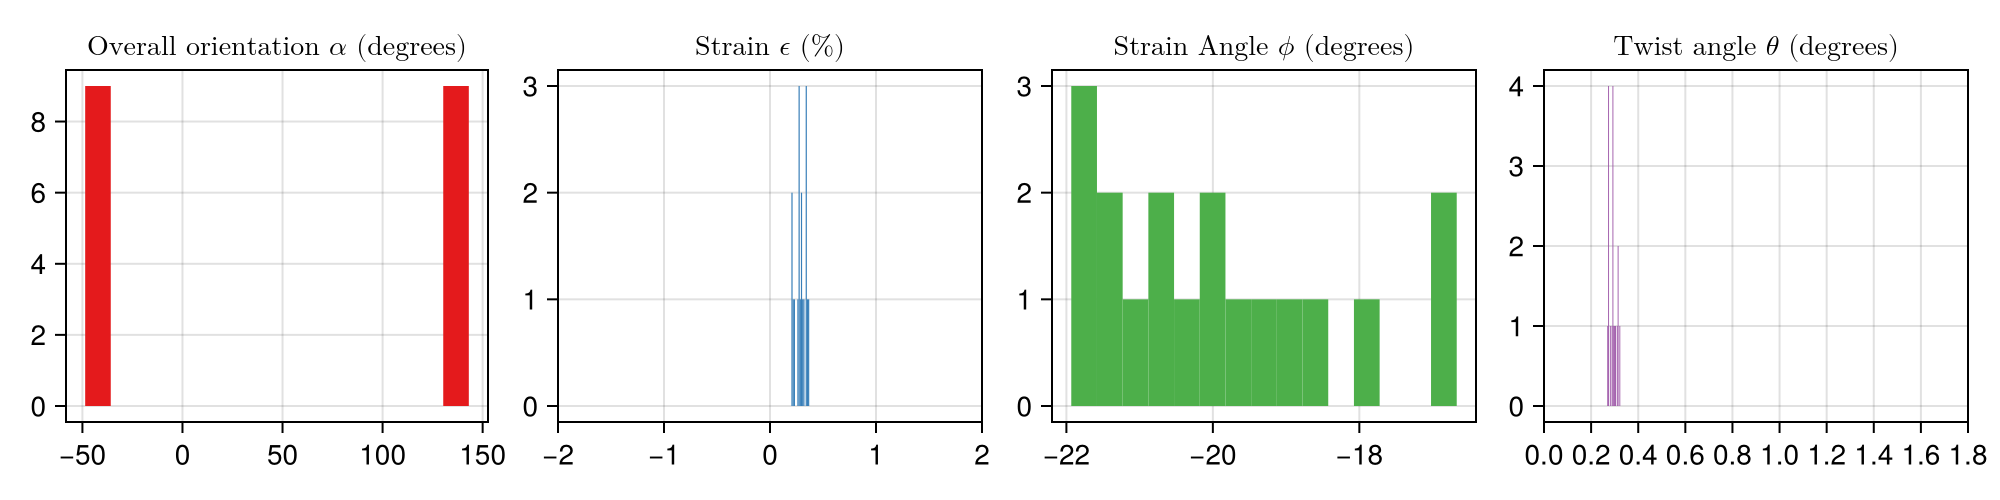

In [291]:
combined = hcat(fit_params1, fit_params2)
println("mean strain: ", mean((combined[2,:])))
println("strain std: ", std((combined[2,:])))
println("mean angle: ", rad2deg(mean(combined[4,:])))
println("angle std: ", rad2deg(std(combined[4,:])))

println("alpha mean: ", rad2deg(mean(combined[1,:])))
println("phi mean: ", rad2deg(mean(combined[3,:])))

fig = Figure(size=(1000,250))
ax = Axis(fig[1,1],title=L"Overall orientation $\alpha$ (degrees)")
hist!(ax,rad2deg.(combined[1,:]),color=pal[1])
ax = Axis(fig[1,2],title=L"Strain $\epsilon$ (%)")
hist!(ax,(combined[2,:]),color=pal[2])
xlims!(ax,-2,2)
ax = Axis(fig[1,3],title=L"Strain Angle $\phi$ (degrees)")
hist!(ax,rad2deg.(combined[3,:]),color=pal[3])
ax = Axis(fig[1,4],title=L"Twist angle $\theta$ (degrees)")
hist!(ax,rad2deg.(combined[4,:]),color=pal[4])
xlims!(ax,0,1.8)

fit_params2 = stack(Optim.minimizer.(fits1))

fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Elaina\.julia\packages\Makie\6zcxH\src\scenes.jl:264


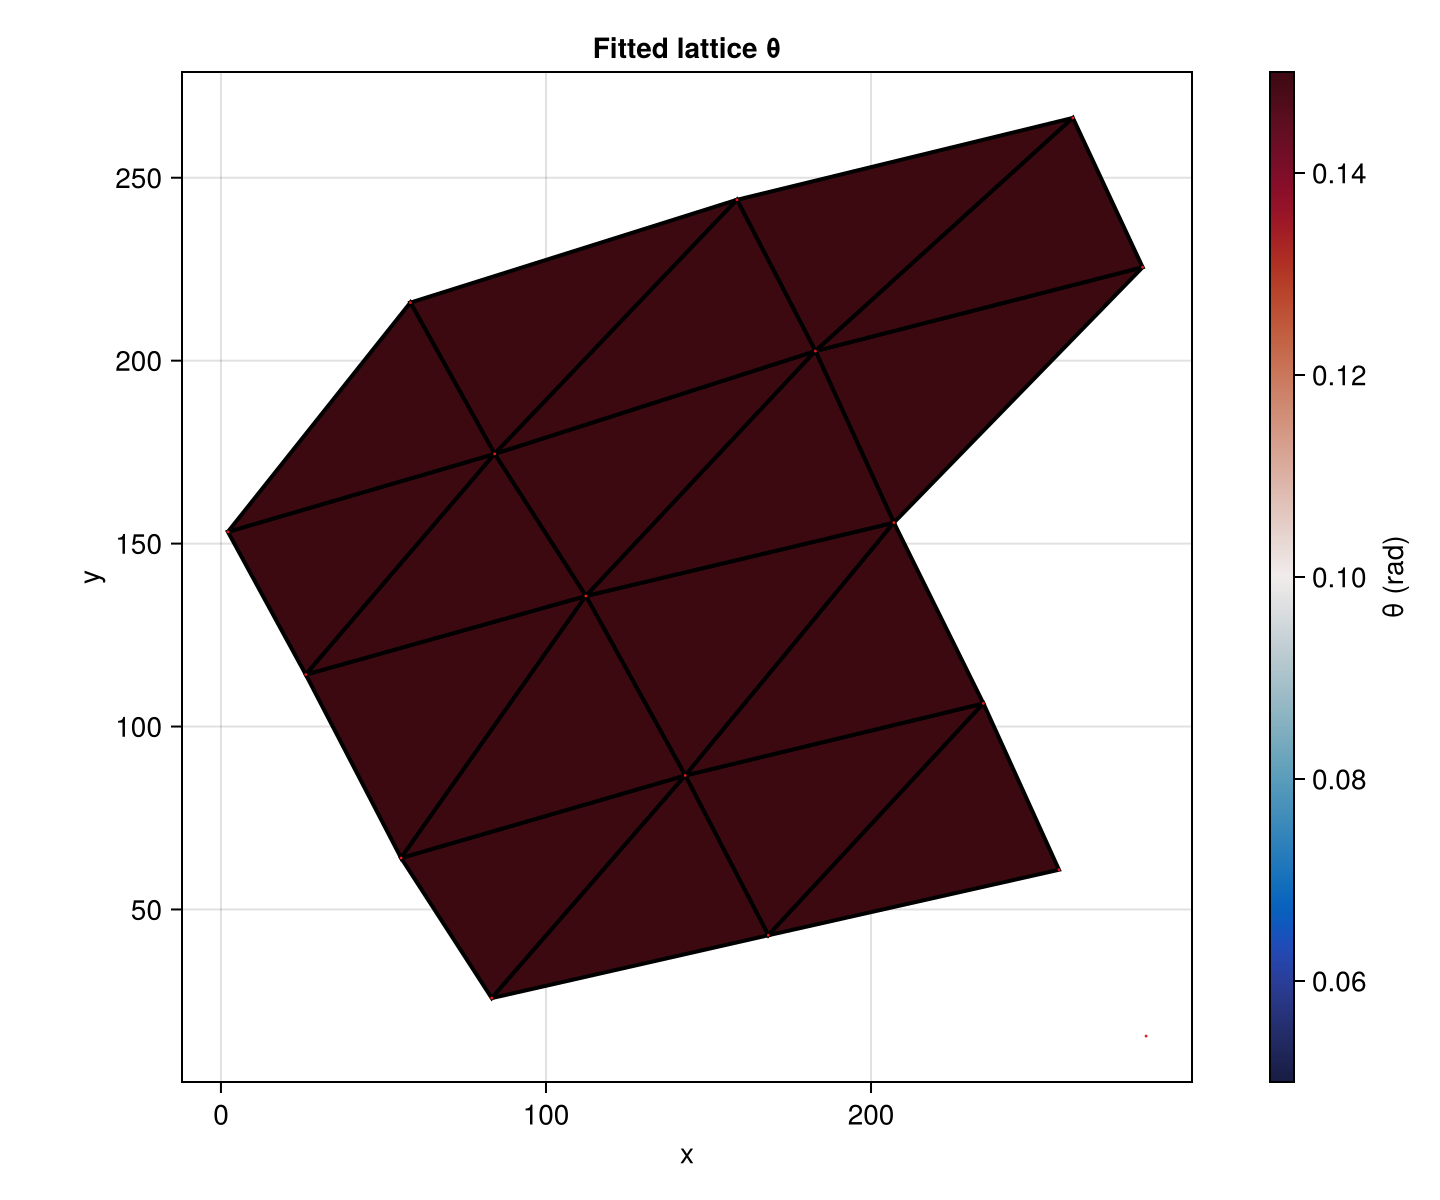

CairoMakie.Screen{IMAGE}


In [293]:
using GeometryBasics: Polygon, Point2f


# Canonicalize so L's edge mapping is consistent
ups   = canonicalize.(up_triangles1)
downs = canonicalize.(down_triangles1)

# Polygons (explicit GeometryBasics.Polygon helps Makie)

polys_up   = [Polygon(collect(Point2f.(t))) for t in ups]
polys_down = [Polygon(collect(Point2f.(t))) for t in downs]



# θ values (row 4) for each triangle
vals_up   = vec(rad2deg.(fit_params1[4, :]))
vals_down = vec(rad2deg.(fit_params2[4, :]))

# vals_up   = vec((fit_params1[2, :]))
# vals_down = vec((fit_params2[2, :]))

# Make sure counts match (trim to the shorter if needed)
nu = min(length(polys_up),   length(vals_up))
nd = min(length(polys_down), length(vals_down))
polys = vcat(polys_up[1:nu], polys_down[1:nd])
vals  = vcat(vals_up[1:nu],  vals_down[1:nd])

# Drop NaN/Inf (avoids silent render failures)
mask = isfinite.(vals)
polys = polys[mask]
vals  = vals[mask]

# Symmetric color range around 0 (nice for signed angles)
mabs = maximum(abs.(vals); init = 0.0)
cr   = (0.05, 0.15)

fig = Figure(resolution = (720, 600))
ax  = Axis(fig[1,1], aspect = 1, xlabel = "x", ylabel = "y",
           title = "Fitted lattice θ")

plt = poly!(ax, polys;
    color       = vals,
    colormap    = :balance,
    colorrange  = cr,
    strokecolor = :black,
    strokewidth = 2)

Colorbar(fig[1,2], plt, label = "θ (rad)")
scatter!(ax, vertices; markersize = 2)

display(fig)  # or just: fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Elaina\.julia\packages\Makie\6zcxH\src\scenes.jl:264


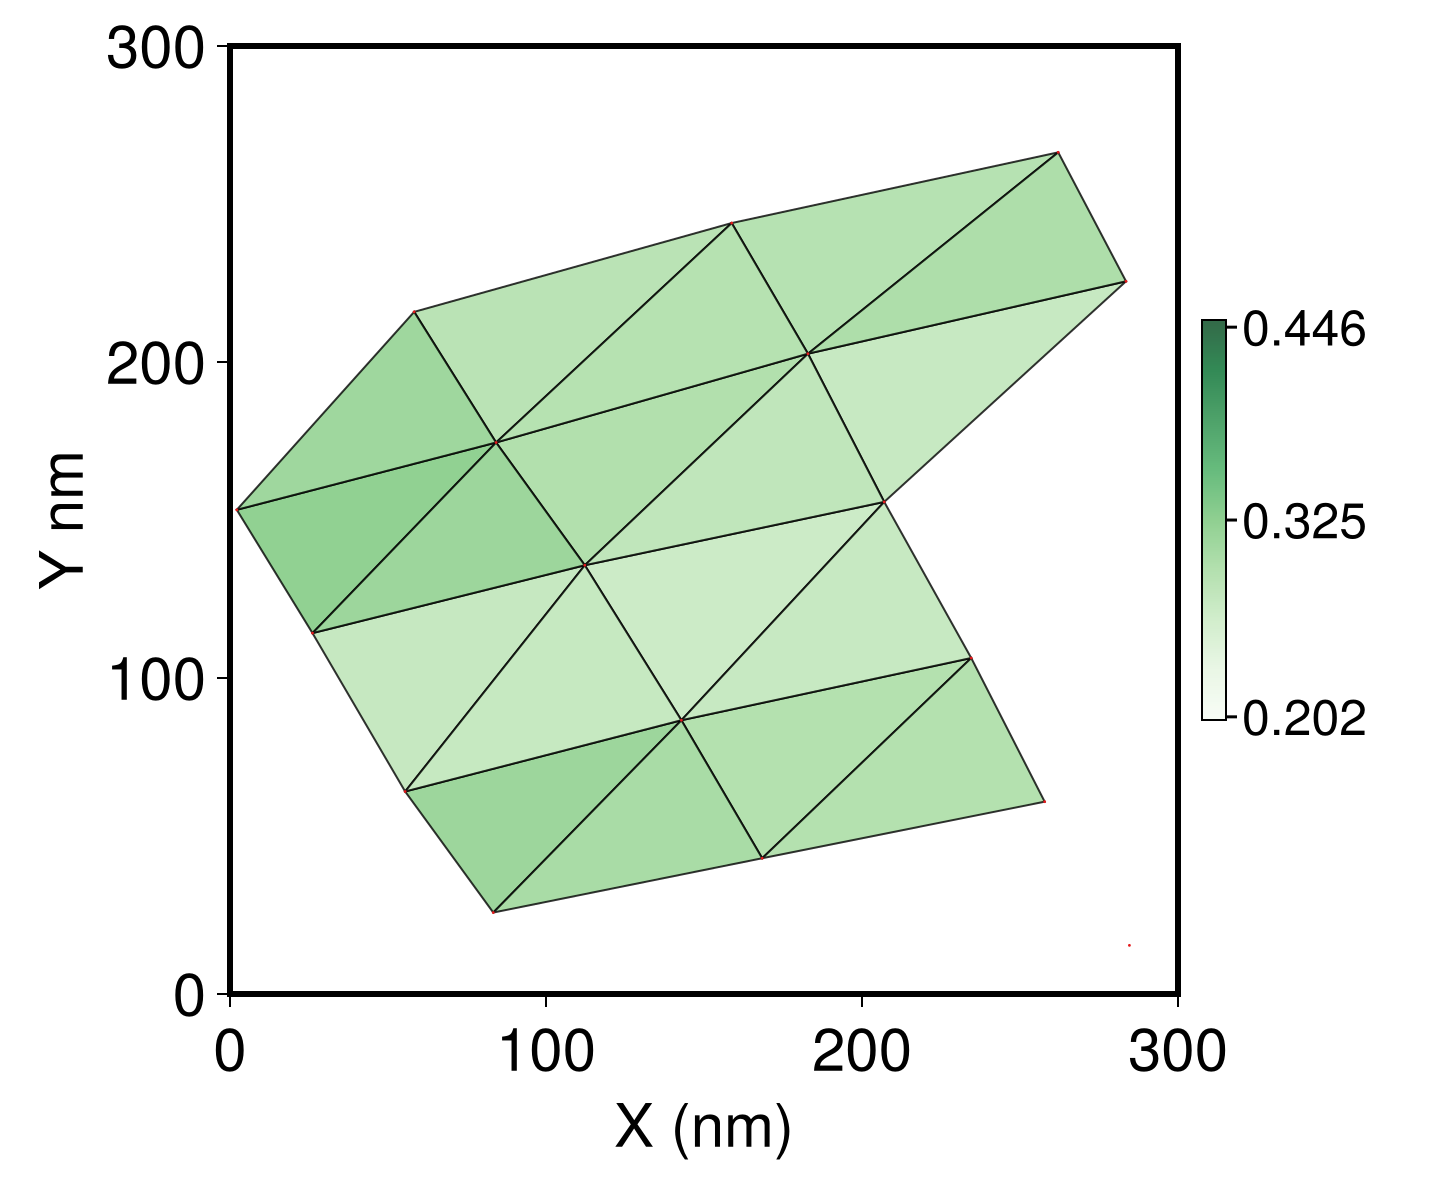

CairoMakie.Screen{IMAGE}


In [295]:
# Symmetric color range around 0 (nice for signed angles)
mabs = maximum(abs.(vals); init = 0.0)
cr   = (0.2, 0.45)

fig = Figure(resolution = (720, 600))
ax  = Axis(fig[1,1], aspect = 1, xlabel = "X (nm)", ylabel = "Y nm", title = "")
ax.spinewidth = 3
# 1) bigger labels + fewer ticks + no grid
ax.xlabelsize = 30
ax.ylabelsize = 30
ax.xticklabelsize = 30
ax.yticklabelsize = 30
ax.xticks = LinearTicks(3)
ax.yticks = LinearTicks(3)
ax.xgridvisible = false
ax.ygridvisible = false

plt = poly!(ax, polys;
    color       = vals,
    colormap    = :Greens,
    colorrange  = cr,
    alpha       = 0.8,
    strokecolor = :black,
    strokewidth = 1)

# --- Only three ticks on the colorbar: bottom, middle, top ---
mid = (cr[1] + cr[2]) / 2
cb = Colorbar(fig[1,2], plt; ticks = [1.01*cr[1], mid, 0.99*cr[2]])

using Makie: colsize!, colgap!, Fixed

colsize!(fig.layout, 2, Fixed(55))
colgap!(fig.layout, -10)
cb.tellheight = false 
cb.height = 200
cb.ticksize      = 5
cb.tickwidth     = 1.5
cb.ticklabelpad  = 2
cb.labelsize     = 25
cb.ticklabelsize = 25

using Printf
cb.tickformat = xs -> [@sprintf("%.3f", x) for x in xs]


xlims!(ax, 0, 300)
ylims!(ax, 0, 300)
scatter!(ax, vertices; markersize = 2)

display(fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Elaina\.julia\packages\Makie\6zcxH\src\scenes.jl:264


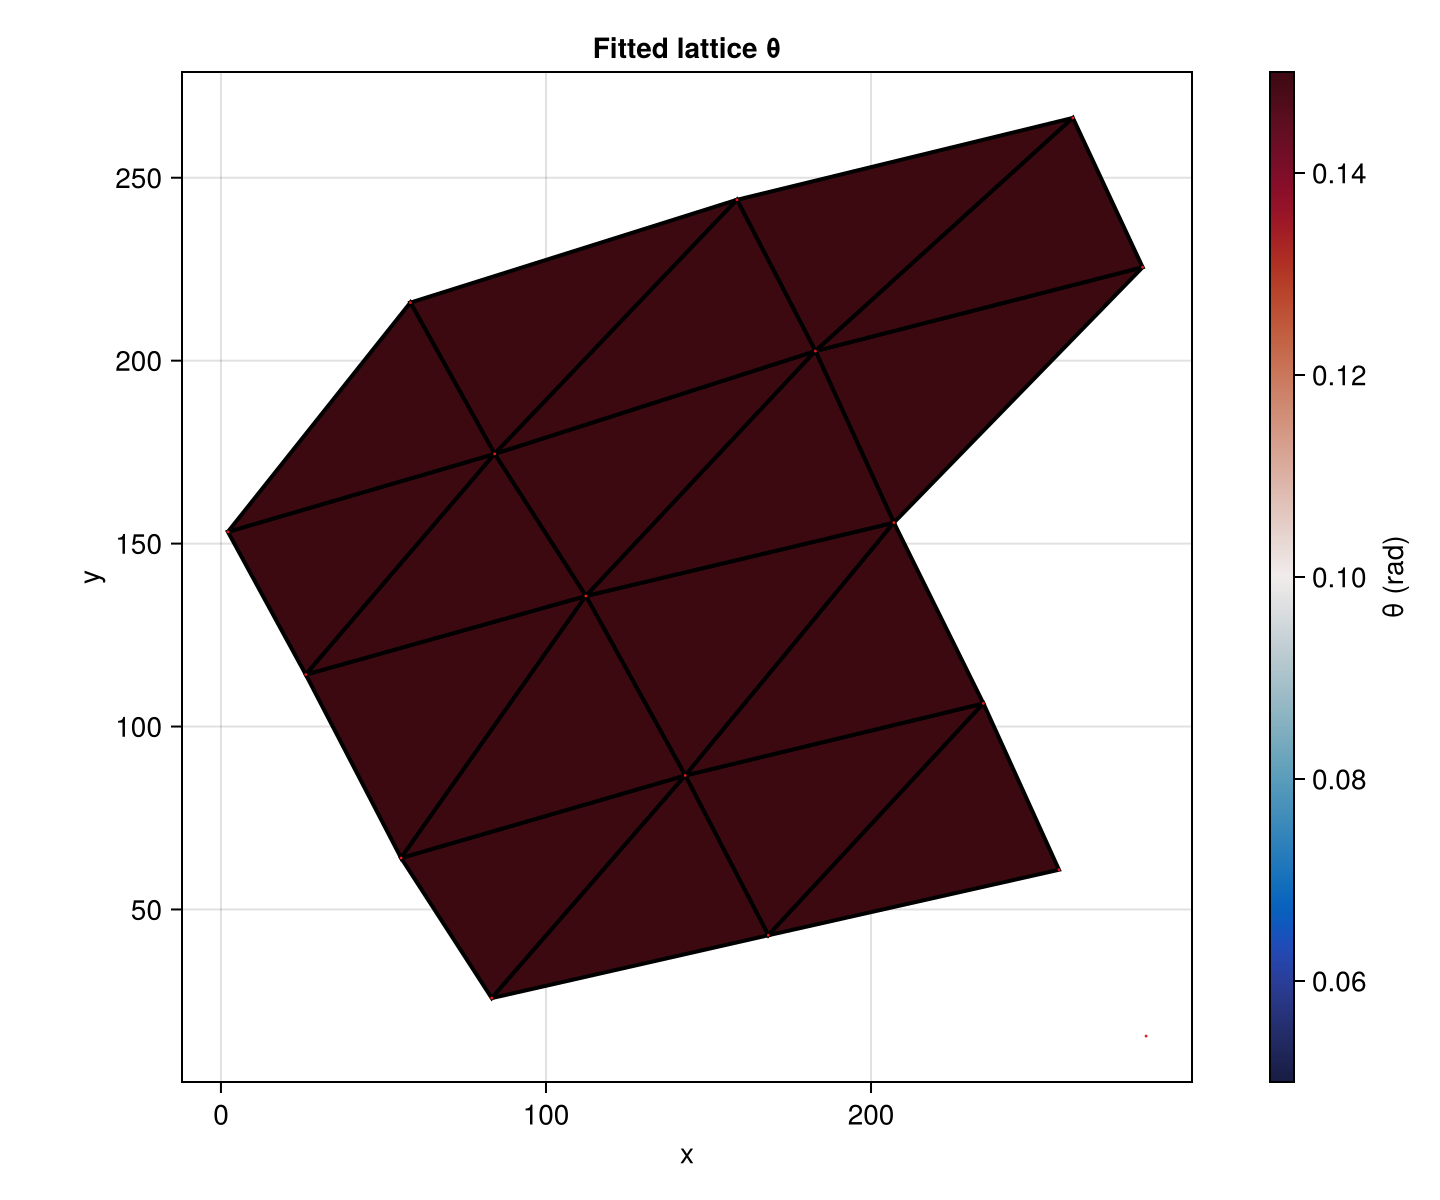

CairoMakie.Screen{IMAGE}


In [297]:
using GeometryBasics: Polygon, Point2f


# Canonicalize so L's edge mapping is consistent
ups   = canonicalize.(up_triangles1)
downs = canonicalize.(down_triangles1)

# Polygons (explicit GeometryBasics.Polygon helps Makie)

polys_up   = [Polygon(collect(Point2f.(t))) for t in ups]
polys_down = [Polygon(collect(Point2f.(t))) for t in downs]

vals_up   = vec((abs.(fit_params1[2, :])))
vals_down = vec((abs.(fit_params2[2, :])))

# Make sure counts match (trim to the shorter if needed)
nu = min(length(polys_up),   length(vals_up))
nd = min(length(polys_down), length(vals_down))
polys = vcat(polys_up[1:nu], polys_down[1:nd])
vals  = vcat(vals_up[1:nu],  vals_down[1:nd])

# Drop NaN/Inf (avoids silent render failures)
mask = isfinite.(vals)
polys = polys[mask]
vals  = vals[mask]

# Symmetric color range around 0 (nice for signed angles)
mabs = maximum(abs.(vals); init = 0.0)
cr   = (0.05, 0.15)

fig = Figure(resolution = (720, 600))
ax  = Axis(fig[1,1], aspect = 1, xlabel = "x", ylabel = "y",
           title = "Fitted lattice θ")

plt = poly!(ax, polys;
    color       = vals,
    colormap    = :balance,
    colorrange  = cr,
    strokecolor = :black,
    strokewidth = 2)

Colorbar(fig[1,2], plt, label = "θ (rad)")
scatter!(ax, vertices; markersize = 2)

display(fig)  # or just: fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Elaina\.julia\packages\Makie\6zcxH\src\scenes.jl:264


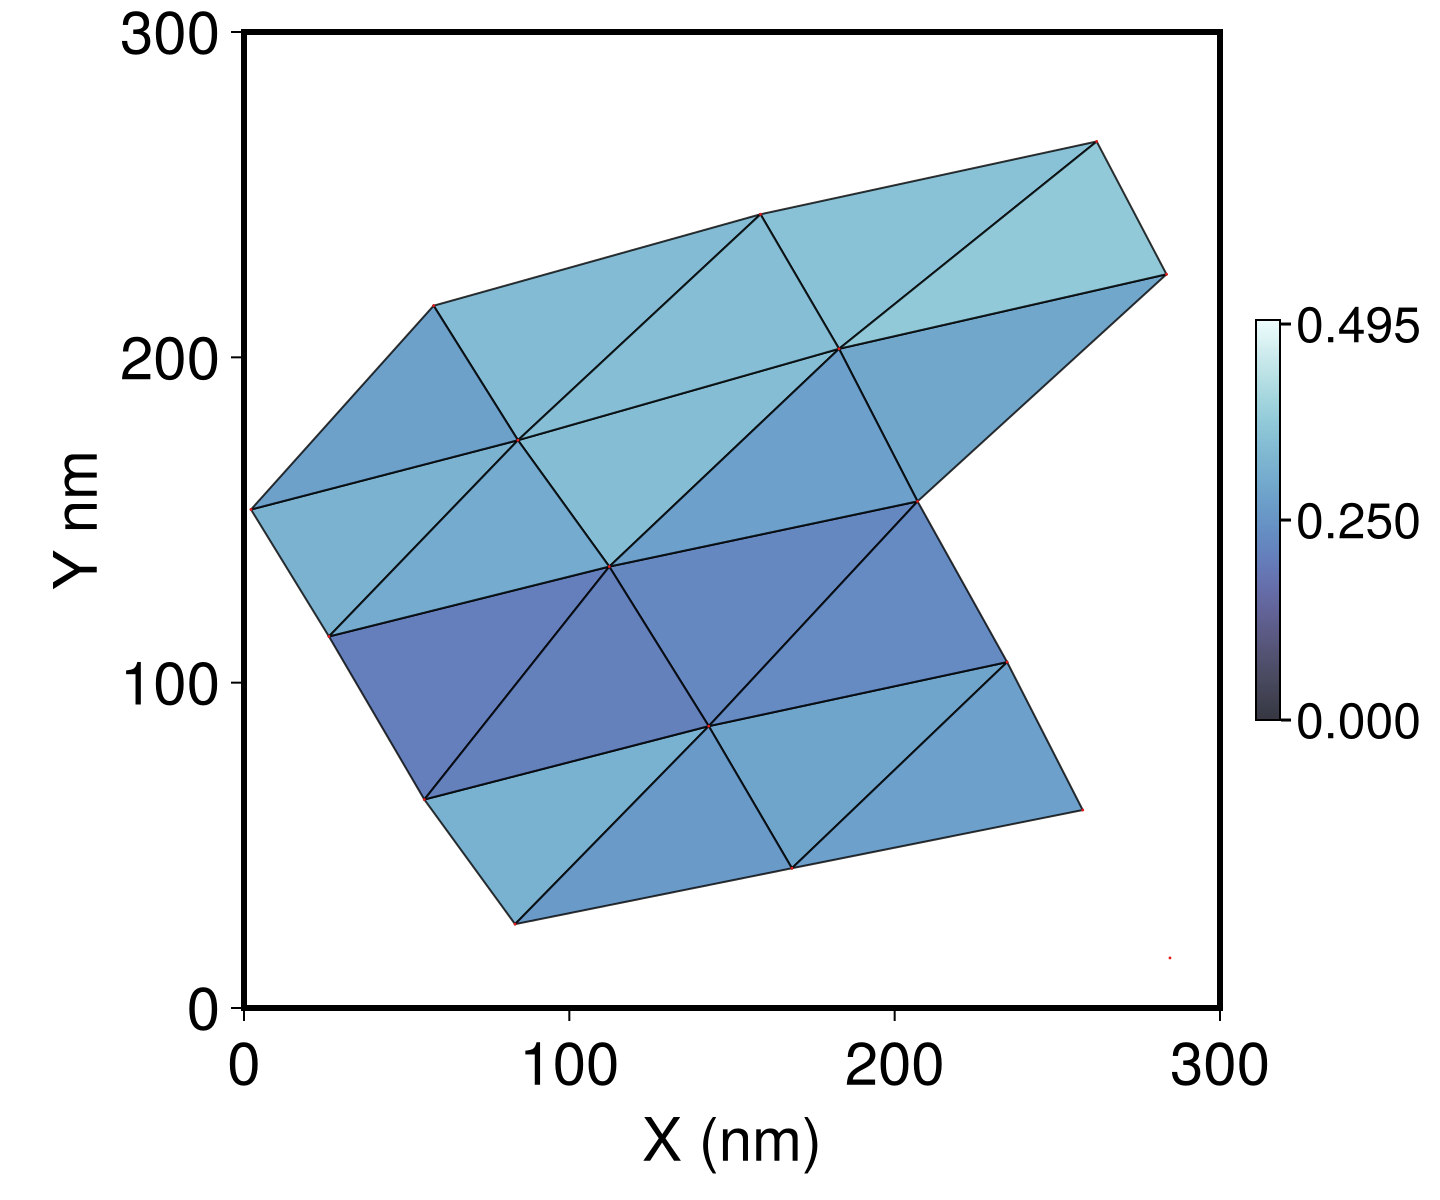

CairoMakie.Screen{IMAGE}


In [299]:
# Symmetric color range around 0 (nice for signed angles)
mabs = maximum(abs.(vals); init = 0.0)
cr   = (0, 0.5)

fig = Figure(resolution = (720, 600))
ax  = Axis(fig[1,1], aspect = 1, xlabel = "X (nm)", ylabel = "Y nm",
           title = "")

ax.spinewidth = 3
ax.leftspinecolor   = :black
ax.rightspinecolor  = :black
ax.topspinecolor    = :black
ax.bottomspinecolor = :black

# 1) bigger labels + fewer ticks + no grid
ax.xlabelsize = 30
ax.ylabelsize = 30
ax.xticklabelsize = 30
ax.yticklabelsize = 30
ax.xticks = LinearTicks(3)
ax.yticks = LinearTicks(3)
ax.xgridvisible = false
ax.ygridvisible = false

plt = poly!(ax, polys;
    color       = vals,
    colormap    = :ice,
    colorrange  = cr,
    alpha       = 0.8,
    strokecolor = :black,
    strokewidth = 1)


# normal colorbar to the right
mid = (cr[1] + cr[2]) / 2
cb = Colorbar(fig[1,2], plt; ticks = [1.01*cr[1], mid, 0.99*cr[2]])

# keep the plot large (optional but recommended)
using Makie: colsize!, colgap!, Fixed
colsize!(fig.layout, 2, Fixed(55))   # sane colorbar column width
colgap!(fig.layout, -10)
cb.tellheight = false 
cb.height = 200
cb.ticksize      = 5      # tick length
cb.tickwidth     = 1.5    # tick line width
cb.ticklabelpad  = 2      # gap between ticks and numbers
cb.labelsize     = 25
cb.ticklabelsize = 25



xlims!(ax, 0, 300)
ylims!(ax, 0, 300)

scatter!(ax, vertices; markersize = 2)

display(fig)  # or just: fig